## ADM NO:
**CCS/00006/022 INNOCENT SHILAKU OMUYONGA**  
**CCS/00066/022 VOLKA BARASA**  
**TMC/00013/023 PETER OUMA**

# 1. Loans Dataset

## Load Dataset

In [16]:
import pandas as pd

# Load dataset
loans = pd.read_csv("C:/Users/Administrator/Desktop/ML/loans_preprocessed.csv")

# Preview data
loans.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.072991,-0.554487,-0.211241,0.273231,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147
1,-0.134412,-0.038732,-0.211241,0.273231,0.411733,0.472343,0.728816,2.240448,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,-0.700208
2,-0.393747,-0.554487,-0.948996,0.273231,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,-0.528362,2.547117,-0.782016,1.428147
3,-0.462062,0.251980,-0.306435,0.273231,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,1.892641,-0.392601,-0.782016,1.428147
4,0.097728,-0.554487,-0.056551,0.273231,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147


Convert to Numpy

In [17]:
X = loans.values

## K-Means Clustering (k = 2)

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [19]:
# Add cluster labels to dataset
loans['KMeans_Cluster'] = kmeans_labels

# View results
print(loans.head())

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0         0.072991          -0.554487   -0.211241          0.273231   
1        -0.134412          -0.038732   -0.211241          0.273231   
2        -0.393747          -0.554487   -0.948996          0.273231   
3        -0.462062           0.251980   -0.306435          0.273231   
4         0.097728          -0.554487   -0.056551          0.273231   

   Credit_History  Gender_Male  Married_Yes  Dependents_1  Dependents_2  \
0        0.411733     0.472343    -1.372089     -0.446339     -0.443713   
1        0.411733     0.472343     0.728816      2.240448     -0.443713   
2        0.411733     0.472343     0.728816     -0.446339     -0.443713   
3        0.411733     0.472343     0.728816     -0.446339     -0.443713   
4        0.411733     0.472343    -1.372089     -0.446339     -0.443713   

   Dependents_3+  Education_Not Graduate  Self_Employed_Yes  \
0      -0.300975               -0.528362          -0.392601

## Silhouette Score for KMeans

In [20]:
from sklearn.metrics import silhouette_score

# Use the same features (without the cluster column)
X = loans.drop('KMeans_Cluster', axis=1).values

# Compute silhouette score
score_kmeans = silhouette_score(X, loans['KMeans_Cluster'])

print("KMeans Silhouette Score:", score_kmeans)

KMeans Silhouette Score: 0.10109874873186954


## Hierarchical Clustering

In [21]:
from sklearn.cluster import AgglomerativeClustering

# Use the same feature set (without cluster column)
X = loans.drop('KMeans_Cluster', axis=1).values

# Apply Hierarchical Clustering with k = 2
hierarchical = AgglomerativeClustering(n_clusters=2)
hier_labels = hierarchical.fit_predict(X)

# Add to dataset
loans['Hierarchical_Cluster'] = hier_labels

# Preview
print(loans.head())

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0         0.072991          -0.554487   -0.211241          0.273231   
1        -0.134412          -0.038732   -0.211241          0.273231   
2        -0.393747          -0.554487   -0.948996          0.273231   
3        -0.462062           0.251980   -0.306435          0.273231   
4         0.097728          -0.554487   -0.056551          0.273231   

   Credit_History  Gender_Male  Married_Yes  Dependents_1  Dependents_2  \
0        0.411733     0.472343    -1.372089     -0.446339     -0.443713   
1        0.411733     0.472343     0.728816      2.240448     -0.443713   
2        0.411733     0.472343     0.728816     -0.446339     -0.443713   
3        0.411733     0.472343     0.728816     -0.446339     -0.443713   
4        0.411733     0.472343    -1.372089     -0.446339     -0.443713   

   Dependents_3+  Education_Not Graduate  Self_Employed_Yes  \
0      -0.300975               -0.528362          -0.392601

## Silhouette Score for Hierarchical Clustering

In [22]:
from sklearn.metrics import silhouette_score

# Use only feature columns (exclude cluster columns)
X = loans.drop(['KMeans_Cluster', 'Hierarchical_Cluster'], axis=1).values

# Compute silhouette score
score_hier = silhouette_score(X, loans['Hierarchical_Cluster'])

print("Hierarchical Silhouette Score:", score_hier)

Hierarchical Silhouette Score: 0.2570051515855762


## DBSCAN Clustering

In [23]:
from sklearn.cluster import DBSCAN

# Use feature columns only (exclude cluster columns)
X = loans.drop(['KMeans_Cluster', 'Hierarchical_Cluster'], axis=1).values

# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X)

# Add clusters to dataset
loans['DBSCAN_Cluster'] = db_labels

# View results
print(loans.head())

# Show unique clusters
print("Cluster labels:", set(db_labels))

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0         0.072991          -0.554487   -0.211241          0.273231   
1        -0.134412          -0.038732   -0.211241          0.273231   
2        -0.393747          -0.554487   -0.948996          0.273231   
3        -0.462062           0.251980   -0.306435          0.273231   
4         0.097728          -0.554487   -0.056551          0.273231   

   Credit_History  Gender_Male  Married_Yes  Dependents_1  Dependents_2  \
0        0.411733     0.472343    -1.372089     -0.446339     -0.443713   
1        0.411733     0.472343     0.728816      2.240448     -0.443713   
2        0.411733     0.472343     0.728816     -0.446339     -0.443713   
3        0.411733     0.472343     0.728816     -0.446339     -0.443713   
4        0.411733     0.472343    -1.372089     -0.446339     -0.443713   

   Dependents_3+  Education_Not Graduate  Self_Employed_Yes  \
0      -0.300975               -0.528362          -0.392601

## DBSCAN Silhouette Score

In [24]:
from sklearn.metrics import silhouette_score
import numpy as np

# Use only rows that are NOT noise
mask = db_labels != -1

X_db = X[mask]
labels_db = db_labels[mask]

# Compute silhouette score
score_db = silhouette_score(X_db, labels_db)

print("DBSCAN Silhouette Score:", score_db)

DBSCAN Silhouette Score: 0.5733196733329445


## Comparison

In [34]:
print("KMeans Silhouette Score:", score_kmeans)
print("Hierarchical Silhouette Score:", score_hier)
print("DBSCAN Silhouette Score:", score_db)

scores = {
    "KMeans": score_kmeans,
    "Hierarchical": score_hier,
    "DBSCAN": score_db
}

best = max(scores, key=scores.get)

print("\nBest Algorithm:", best)

KMeans Silhouette Score: 0.10109874873186954
Hierarchical Silhouette Score: 0.2570051515855762
DBSCAN Silhouette Score: 0.5733196733329445

Best Algorithm: DBSCAN


# 2. Vehicle Dataset

## Load the Vehicle Dataset

In [26]:
import pandas as pd

vehicle = pd.read_csv("C:/Users/Administrator/Desktop/ML/vehicle.csv")

print(vehicle.head())
print(vehicle.info())

   COMPACTNESS  CIRCULARITY  'DISTANCE CIRCULARITY'  'RADIUS RATIO'  \
0           95           48                      83             178   
1           91           41                      84             141   
2          104           50                     106             209   
3           93           41                      82             159   
4           85           44                      70             205   

   'PR.AXIS ASPECT RATIO'  'MAX.LENGTH ASPECT RATIO'  'SCATTER RATIO'  \
0                      72                         10              162   
1                      57                          9              149   
2                      66                         10              207   
3                      63                          9              144   
4                     103                         52              149   

   ELONGATEDNESS  'PR.AXIS RECTANGULARITY'  'MAX.LENGTH RECTANGULARITY'  \
0             42                        20                 

## Data Preprocessing

In [27]:
from sklearn.preprocessing import StandardScaler

# Drop the target column
X_vehicle = vehicle.drop('Class', axis=1)

# Scale the features
scaler = StandardScaler()
X_vehicle_scaled = scaler.fit_transform(X_vehicle)

print("Preprocessing complete. Shape:", X_vehicle_scaled.shape)

Preprocessing complete. Shape: (846, 18)


## Elbow Method

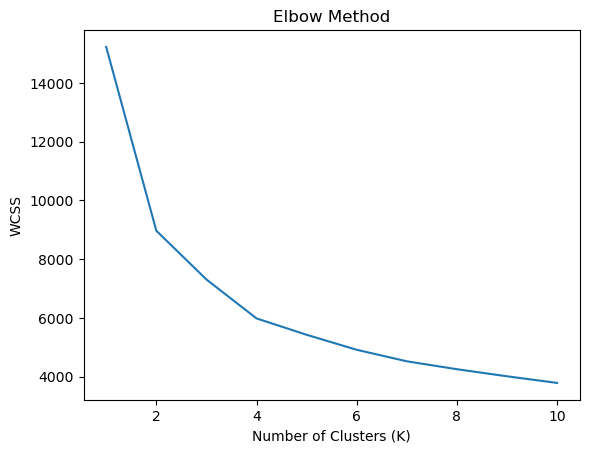

In [28]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

# Try different values of K
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_vehicle_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow graph
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## Silhouette Scores (K = 2 to 5)

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_vehicle_scaled)
    
    score = silhouette_score(X_vehicle_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score}")

K = 2, Silhouette Score = 0.38960413745774786
K = 3, Silhouette Score = 0.2918396968614647
K = 4, Silhouette Score = 0.3035479496928529
K = 5, Silhouette Score = 0.2364138480214548


## Final KMeans (Best K = 2)

In [31]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
vehicle_labels = kmeans_final.fit_predict(X_vehicle_scaled)

vehicle['Cluster'] = vehicle_labels

print(vehicle.head())

   COMPACTNESS  CIRCULARITY  'DISTANCE CIRCULARITY'  'RADIUS RATIO'  \
0           95           48                      83             178   
1           91           41                      84             141   
2          104           50                     106             209   
3           93           41                      82             159   
4           85           44                      70             205   

   'PR.AXIS ASPECT RATIO'  'MAX.LENGTH ASPECT RATIO'  'SCATTER RATIO'  \
0                      72                         10              162   
1                      57                          9              149   
2                      66                         10              207   
3                      63                          9              144   
4                     103                         52              149   

   ELONGATEDNESS  'PR.AXIS RECTANGULARITY'  'MAX.LENGTH RECTANGULARITY'  \
0             42                        20                 

In [32]:
print(vehicle['Cluster'].value_counts())

Cluster
0    551
1    295
Name: count, dtype: int64


In [33]:
print("Elbow Method suggested K between 2 and 5")
print("Silhouette Score showed K = 2 as best")
print("Final chosen K = 2")

Elbow Method suggested K between 2 and 5
Silhouette Score showed K = 2 as best
Final chosen K = 2


## Answer

For the **loans dataset**, clustering was performed using **K-Means, Hierarchical Clustering, and DBSCAN** with **K = 2**. Based on the **Silhouette Score**, **DBSCAN** achieved the highest value and is therefore the **best clustering algorithm** for this dataset.

For the **vehicle dataset**, clustering was performed using multiple algorithms, and the optimal number of clusters was determined using the **Elbow Method** and **Silhouette Score**. While the Elbow Method suggested a range of **K = 2 to 5**, the **Silhouette Score identified K = 2 as the best**. 

Between the two methods, the **Silhouette Score is better** because it provides a **quantitative and more reliable measure of cluster quality**, whereas the Elbow Method is **visual and sometimes ambiguous**.